# 17_02 분포·범주·관계 시각화 실습

In [1]:
import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

system_name = platform.system()
if system_name == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif system_name == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
    if nanum_fonts:
        plt.rcParams['font.family'] = nanum_fonts[0]
    else:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
        fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
        plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('17_열처리.csv')
df.head()

  측정시각    배치     온도   OP값    CP값  상태
0  09:00  로트A  861.9  42.9  0.451  정상
1  09:10  로트A  858.4  97.6  0.446  정상
2  09:20  로트A  858.7  89.8  0.450  정상
3  09:30  로트A  860.7  57.3  0.450  정상
4  09:40  로트A  859.1  87.8  0.452  정상

## 실습 1

배치
로트A    858.420000
로트B    859.813333
로트C    860.421429
Name: 온도, dtype: float64


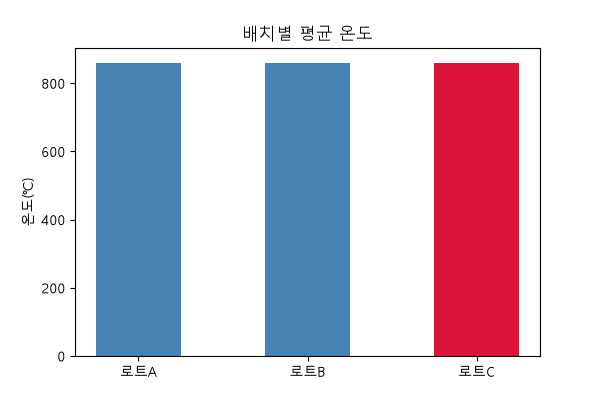

In [3]:
avg_temp = df.groupby('배치')['온도'].mean()
print(avg_temp)

max_batch = avg_temp.idxmax()
colors = ['crimson' if b == max_batch else 'steelblue' for b in avg_temp.index]

plt.figure(figsize=(6, 4))
plt.bar(avg_temp.index, avg_temp.values, color=colors, width=0.5)
plt.title('배치별 평균 온도')
plt.ylabel('온도(℃)')
plt.show()

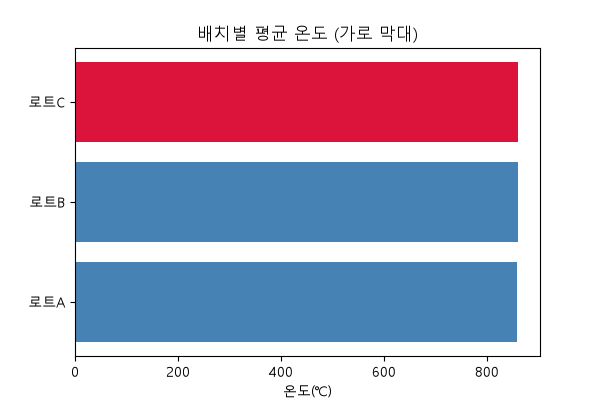

In [4]:
plt.figure(figsize=(6, 4))
plt.barh(avg_temp.index, avg_temp.values, color=colors)
plt.title('배치별 평균 온도 (가로 막대)')
plt.xlabel('온도(℃)')
plt.show()

## 실습 2

상태
정상    42
승온     2
Name: count, dtype: int64


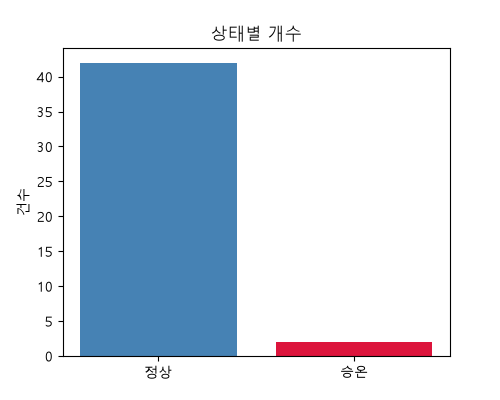

In [5]:
status_counts = df['상태'].value_counts()
print(status_counts)

plt.figure(figsize=(5, 4))
plt.bar(status_counts.index, status_counts.values, color=['steelblue', 'crimson'])
plt.title('상태별 개수')
plt.ylabel('건수')
plt.show()

배치
로트A    81.906667
로트B    75.840000
로트C    69.621429
Name: OP값, dtype: float64


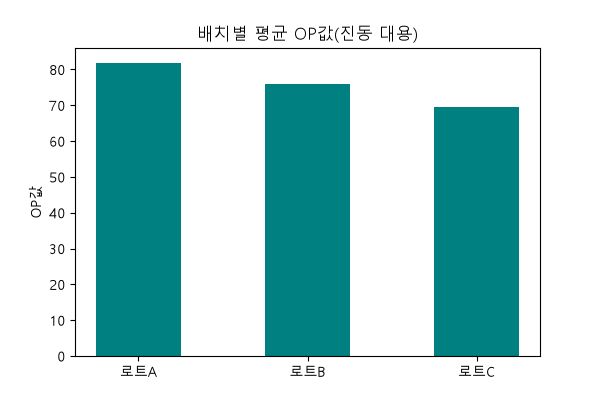

In [6]:
avg_op = df.groupby('배치')['OP값'].mean()
print(avg_op)

plt.figure(figsize=(6, 4))
plt.bar(avg_op.index, avg_op.values, color='teal', width=0.5)
plt.title('배치별 평균 OP값')
plt.ylabel('OP값')
plt.show()

## 실습 3

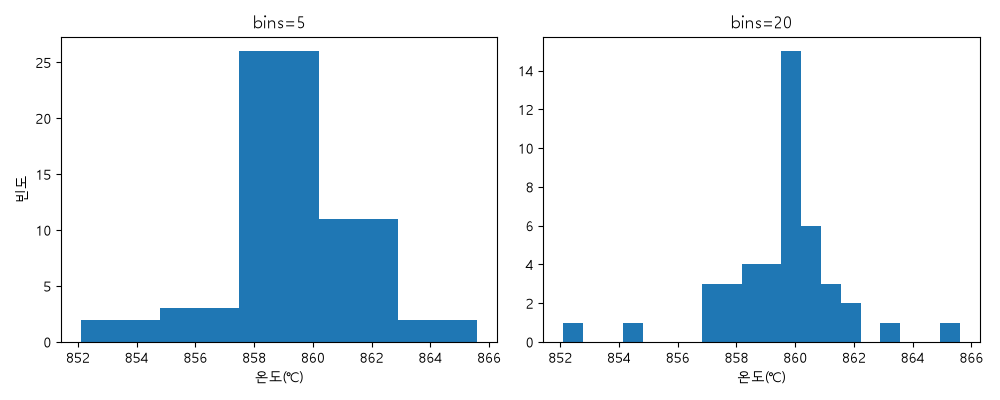

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['온도'], bins=5)
plt.title('bins=5')
plt.xlabel('온도(℃)')
plt.ylabel('빈도')

plt.subplot(1, 2, 2)
plt.hist(df['온도'], bins=20)
plt.title('bins=20')
plt.xlabel('온도(℃)')

plt.tight_layout()
plt.show()

## 실습 4

In [8]:
mean_t = df['온도'].mean()
std_t = df['온도'].std()
print('평균', round(mean_t, 2), '표준편차', round(std_t, 2))

upper = mean_t + 1.5 * std_t
lower = mean_t - 1.5 * std_t
outliers = df[(df['온도'] > upper) | (df['온도'] < lower)]
print('정상 범위', round(lower, 2), '~', round(upper, 2))
print('범위를 벗어난 측정 수', len(outliers))
outliers[['측정시각', '배치', '온도']]

평균 859.53 표준편차 2.11
정상 범위 856.37 ~ 862.69
범위를 벗어난 측정 수 4


   측정시각    배치     온도
7   10:10  로트A  852.1
12  11:00  로트A  854.3
25  10:40  로트B  862.9
32  09:30  로트C  865.6

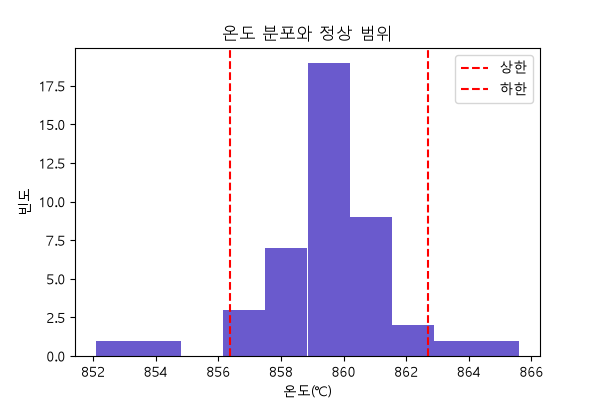

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(df['온도'], bins=10, color='slateblue')
plt.axvline(x=upper, color='red', linestyle='--', label='정상 범위 경계')
plt.axvline(x=lower, color='red', linestyle='--')
plt.title('온도 분포와 정상 범위')
plt.xlabel('온도(℃)')
plt.ylabel('빈도')
plt.legend()
plt.show()

## 실습 5

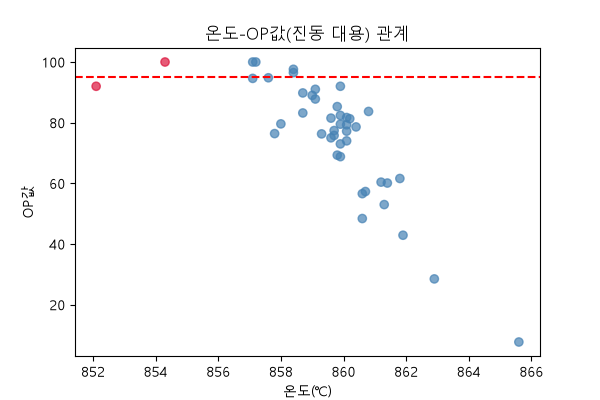

온도-OP값 상관계수 -0.783


In [10]:
color_map = {'정상': 'steelblue', '승온': 'crimson'}
colors5 = df['상태'].map(color_map)

plt.figure(figsize=(6, 4))
plt.scatter(df['온도'], df['OP값'], c=colors5, alpha=0.7)
plt.axhline(y=df['OP값'].mean() + df['OP값'].std(), color='red', linestyle='--')
plt.title('온도-OP값 관계')
plt.xlabel('온도(℃)')
plt.ylabel('OP값')
plt.show()

corr5 = df['온도'].corr(df['OP값'])
print('온도-OP값 상관계수', round(corr5, 3))

## 실습 6

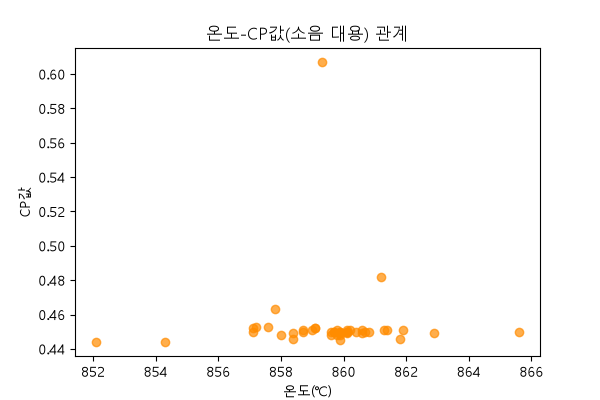

온도-CP값 상관계수 0.022


In [11]:
plt.figure(figsize=(6, 4))
plt.scatter(df['온도'], df['CP값'], alpha=0.7, color='darkorange')
plt.title('온도-CP값 관계')
plt.xlabel('온도(℃)')
plt.ylabel('CP값')
plt.show()

corr6 = df['온도'].corr(df['CP값'])
print('온도-CP값 상관계수', round(corr6, 3))

## 실습 8

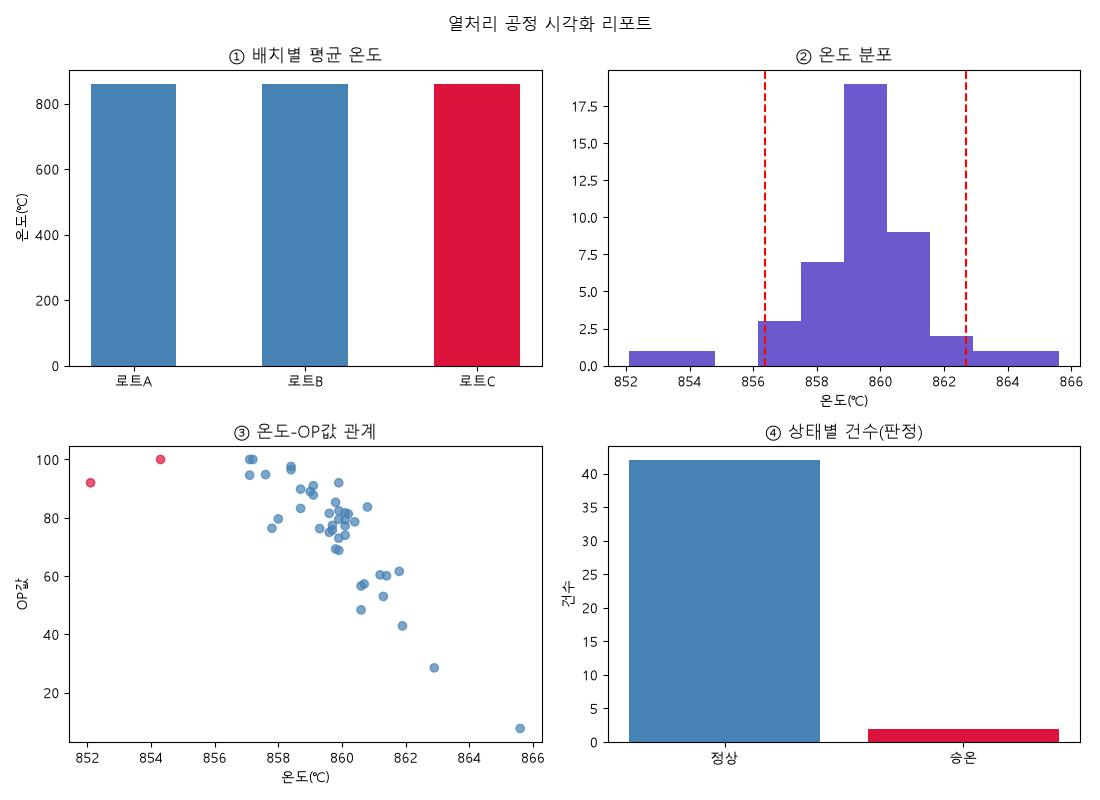

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

plt.sca(axes[0, 0])
plt.bar(avg_temp.index, avg_temp.values, color=colors, width=0.5)
plt.title('① 배치별 평균 온도')
plt.ylabel('온도(℃)')

plt.sca(axes[0, 1])
plt.hist(df['온도'], bins=10, color='slateblue')
plt.axvline(x=upper, color='red', linestyle='--')
plt.axvline(x=lower, color='red', linestyle='--')
plt.title('② 온도 분포')
plt.xlabel('온도(℃)')

plt.sca(axes[1, 0])
plt.scatter(df['온도'], df['OP값'], c=colors5, alpha=0.7)
plt.title('③ 온도-OP값 관계')
plt.xlabel('온도(℃)')
plt.ylabel('OP값')

plt.sca(axes[1, 1])
plt.bar(status_counts.index, status_counts.values, color=['steelblue', 'crimson'])
plt.title('④ 상태별 건수')
plt.ylabel('건수')

plt.suptitle('열처리 공정 시각화 리포트')
plt.tight_layout()
plt.savefig('열처리_시각화_리포트.png')
plt.show()